In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm
from scipy.interpolate import make_smoothing_spline
from sklearn.metrics import r2_score

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

import imageio
import os
import shutil
import sys

PROJECT_ROOT = "../"
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.loaders import load_all_ploidy_liquid, load_all_ploidy, load_stability_results_solid, load_stability_results_liquid, load_ensemble

In [2]:
### Error areas x ###
def return_stats(vec, interv):
    means =[]
    stds = []
    for i in range(len(interv)-1):
        provv = []
        for j in range(len(vec)):
            provv.append(np.where(np.logical_and(vec[j]>interv[i],vec[j]<=interv[i+1]))[0])
        provv = np.concatenate(provv)
        means.append(np.mean(provv))
        stds.append(np.std(provv))
    
    return np.array(means), np.array(stds)

def reconstruct_ymean(mm, space):
    x = []
    for i in range(int(max(mm))):
        p0 = np.where(mm<=i)[0][-1]
        p1 = np.where(mm>i)[0][0]
        slope = space/(mm[p1]-mm[p0])
        x.append(interv_0[p0]+slope*1)
    return np.array(x)

def running_slope(x, skip):
    vec = []
    for i in range(skip, len(x)-skip-1):
        vec.append((x[i+skip]-x[i])/skip)
    return np.array(vec)

### Error areas y ###
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = []
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = np.quantile(arr, 0.5)
            stds.append([np.quantile(arr, 0.159), np.quantile(arr, 0.841)]) # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds.append([np.nan, np.nan])
            
    return np.array(means), np.array(stds)

def plot_stats_elementwise(x, ax, label="", color="C0", lw=3, alpha=0.3):
    means, stds = stats_elementwise(x)
    
    ax.plot(np.arange(len(means)), means, color=color, lw=lw, label=label)
    ax.fill_between(np.arange(len(means)) ,stds[:,0], stds[:,1], color=color, alpha=alpha)

In [26]:
ens = load_ensemble("ensemble_results_D")

In [7]:
ens[1][0].keys()

dict_keys(['tumor_density', 'mut_S', 'mut_I', 'r', 'outcome_code', 'mu', 'act_M', 'act_O', 'n_chrs', 'mut_HK', 'mut_O', 'act_S', 'act_HK', 'death_density', 'dm', 'm', 'mut_M', 'act_I'])

In [37]:
2.17*0.015

0.032549999999999996

In [40]:
1-(1-0.038)**10

0.3211861099415607

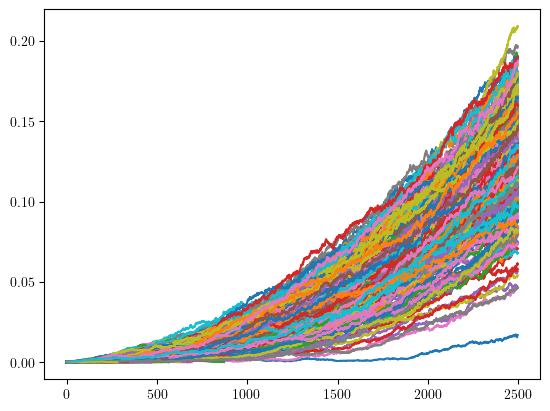

In [27]:
for i in range(1000):
    plt.plot(ens[1][i]['tumor_density'], label=str(i+1))
#plt.legend()

In [28]:
data_l = load_all_ploidy_liquid()
data_s = load_all_ploidy()

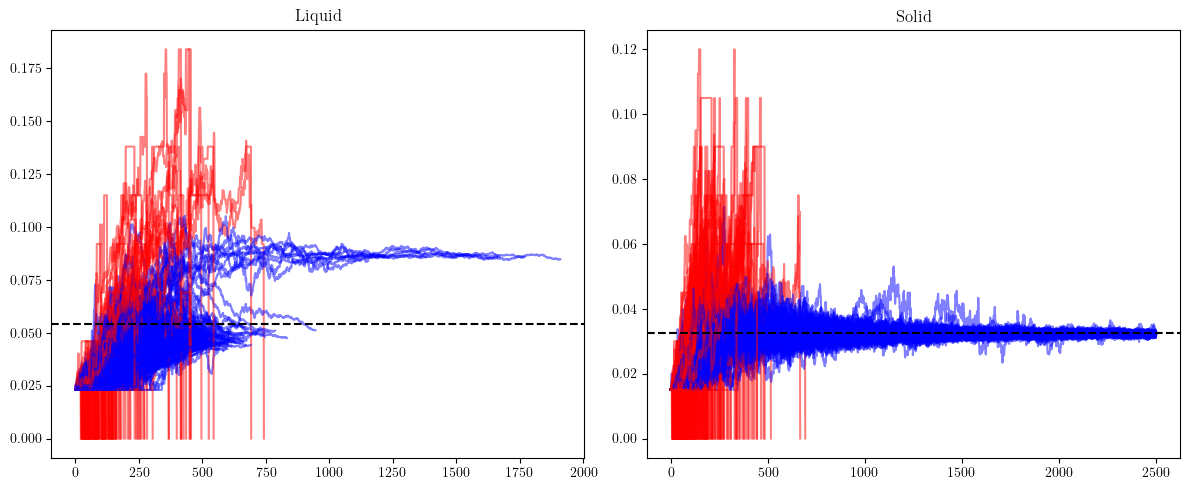

In [29]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

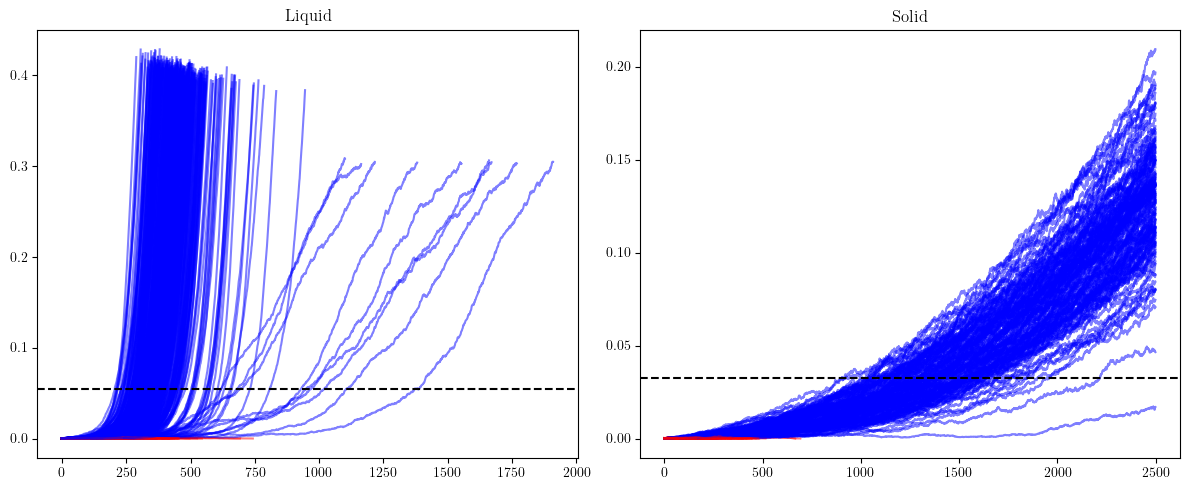

In [30]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

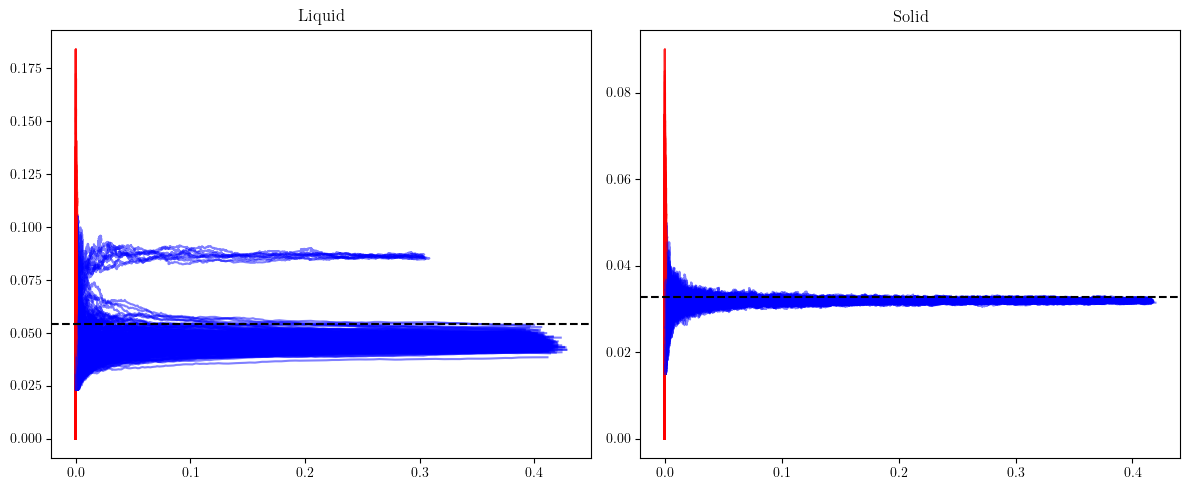

In [8]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['tumor_density'], data_l['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['tumor_density'], data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

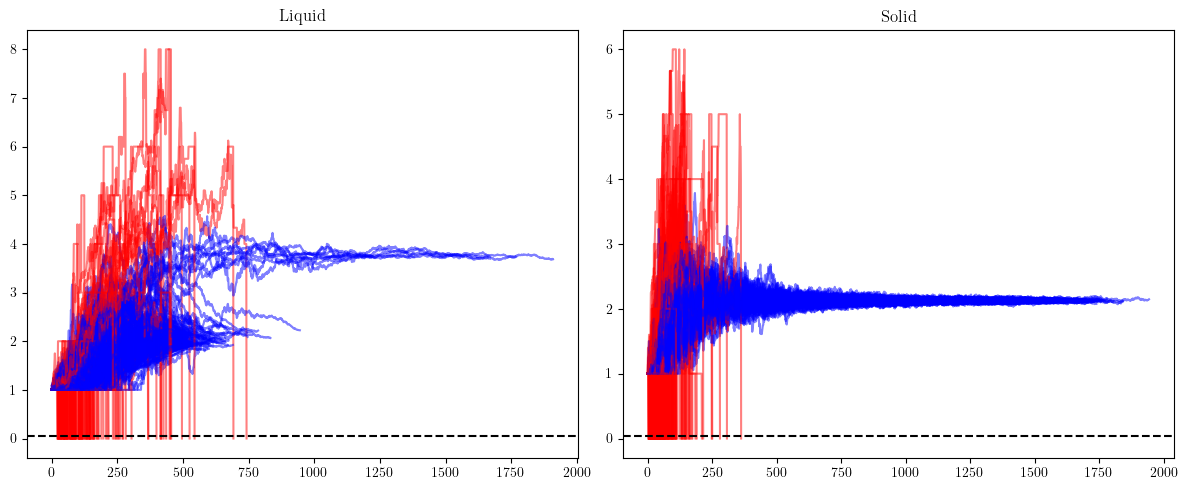

In [9]:
_, ax = plt.subplots(1,2,figsize=(12,5))

for i in range(500):
    if data_l['Diploid'][1][i]['outcome_code']==0:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[0].plot(data_l['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[0].axhline(0.054, color="k", ls="--")
ax[0].set_title("Liquid")

for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="r", alpha=0.5)
    else:
        ax[1].plot(data_s['Diploid'][1][i]['act_I'], color="b", alpha=0.5)

ax[1].axhline(0.032614, color="k", ls="--")
ax[1].set_title("Solid")

plt.tight_layout()

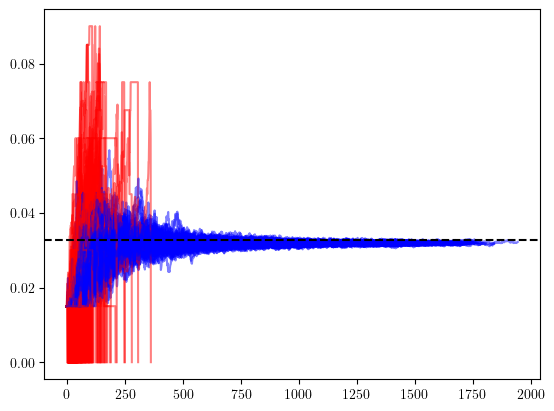

In [10]:
for i in range(500):
    if data_s['Diploid'][1][i]['outcome_code']==0:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="r", alpha=0.5)
    else:
        plt.plot(data_s['Diploid'][1][i]['mu'], color="b", alpha=0.5)

plt.axhline(0.032614, color="k", ls="--")

In [20]:
1-(1/2)**(1/10)

0.06696700846319259

In [ ]:
1-((3/)**(1/10))

-0.04137974399241062

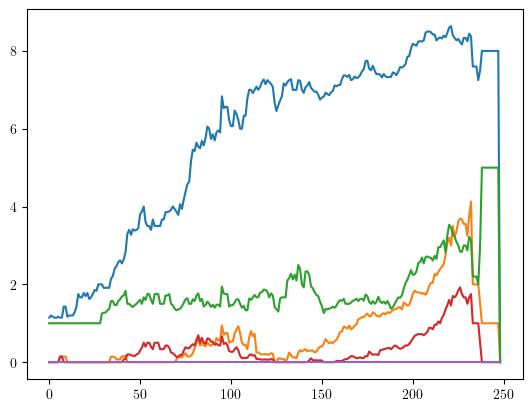

In [9]:
index = 1
plt.plot(data_s['Diploid'][1][index]['act_O'])
plt.plot(data_s['Diploid'][1][index]['act_S'])
plt.plot(data_s['Diploid'][1][index]['act_I'])
plt.plot(data_s['Diploid'][1][index]['act_M'])
plt.plot(data_s['Diploid'][1][index]['act_HK'])

In [3]:
stab = load_stability_results_solid()
stabl = load_stability_results_liquid()

In [67]:
((1-0.15)**10)*(1-((1-0.15)**10))


0.15811487325620827

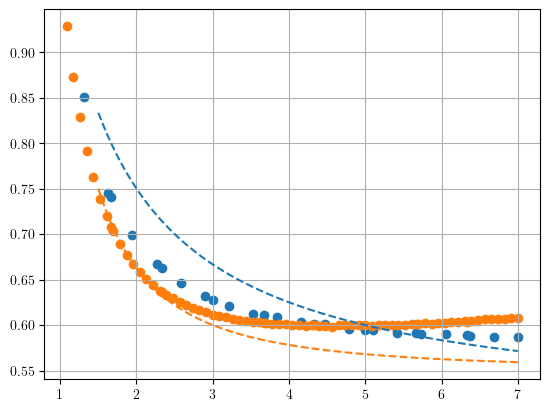

In [16]:
x = np.linspace(1.5,7,100)

def th_s(x):
    #return (1-((1+1/x)/2)**0.1)
    return ((1/2)*(1+(1/x)))

def th_l(x, c=0.1):
    #return (1-((1+1/x)/2)**0.1)
    return (1+c+(1-c)*(1/x)**2)/2
def th_b(x, lb=0):
    a = []
    for xi in x:
        a.append(compute_asymptotic_limit(10,10,xi,lb)['asymp_mu_analytical'])
    return np.array(a)
def ps(x):
    return (1-x)**(10)

#plt.plot(x, pdeath(th_pred(x)))
plt.scatter(stab['rmax_norm'], ps(stab['stable_dmu']*10), color="C0")
plt.plot(x, th_s(x), color="C0", ls="--")
#plt.axhline(compute_asymptotic_limit(10,10,0.017)['asymp_mu_analytical'], c="C0", ls=":")
plt.scatter(stabl['rmax_norm'], ps(stabl['stable_dmu']*10), color="C1")
plt.plot(x, th_l(x), color="C1", ls="--")
plt.grid()

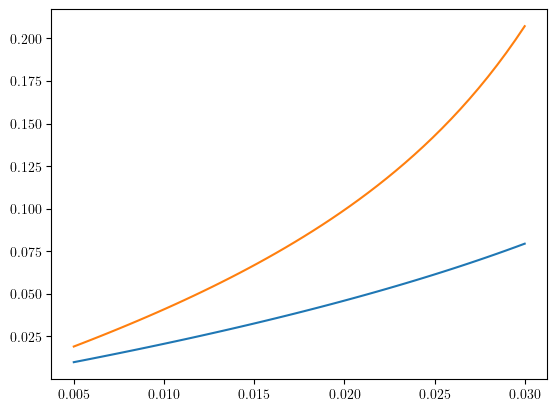

In [56]:
xmu = np.linspace(0.005, 0.03)
plt.plot(xmu, th_b(xmu))
plt.plot(xmu, th_b(xmu,lb=1))

In [30]:
from scripts.calculate_asymptotic_theory import compute_asymptotic_limit

In [35]:
compute_asymptotic_limit(10,10,0.015)['asymp_mu_analytical']

0.032613709914529505

In [39]:
import numpy as np
from scipy.optimize import root
from scipy.optimize import least_squares


class CorrectedLiquidTumor:

    def __init__(self, NI, NHK, delta_mu, r, r0):

        self.NI = NI
        self.NHK = NHK
        self.delta_mu = delta_mu

        self.r = np.asarray(r, dtype=float)
        self.r0 = float(r0)

        self.beta_k = self.r / (self.r + self.r0)

    # ---------------------------------------------------------
    # Mutation probabilities
    # ---------------------------------------------------------

    def sigma(self, k):
        mu = k * self.delta_mu
        return (1.0 - mu) ** self.NHK

    def delta(self, k):
        return 1.0 - self.sigma(k)

    def alpha(self, k):
        mu = k * self.delta_mu
        return (1.0 - mu) ** (self.NHK + self.NI - k)

    def gamma(self, k):

        if k >= self.NI:
            return 0.0

        mu = k * self.delta_mu

        return (
            (self.NI - k)
            * mu
            * (1.0 - mu) ** (self.NHK + self.NI - k - 1)
        )

    # ---------------------------------------------------------
    # Moran probabilities
    # ---------------------------------------------------------

    def beta_kj(self, k, j):

        rk = self.r[k - 1]
        rj = self.r[j - 1]

        if k == j:
            return 0.5

        return rk / (rk + rj)

    # ---------------------------------------------------------
    # Colonisation factors
    # ---------------------------------------------------------

    def compute_phi(self, f, pD):

        fW = 1.0 - pD - np.sum(f)
        phi = np.zeros(self.NI)
        for k in range(1, self.NI + 1):
            value = pD
            value += fW * self.beta_k[k - 1]
            for j in range(1, self.NI + 1):
                value += f[j - 1] * self.beta_kj(k, j)
            phi[k - 1] = value
        return phi, fW

    # ---------------------------------------------------------
    # Steady-state residuals
    # ---------------------------------------------------------

    def residuals(self, x):

        f = x[:-1]
        pD = x[-1]
        phi, fW = self.compute_phi(f, pD)
        res = np.zeros(self.NI + 1)
        # -----------------------------------
        # Cancer classes
        # -----------------------------------

        for k in range(1, self.NI + 1):
            fk = f[k - 1]
            phi_self = fk / 2.0
            phi_nonself = phi[k - 1] - phi_self
            ak = self.alpha(k)
            dk = self.delta(k)
            gk = self.gamma(k)
            # original cancer dynamics
            cancer_term = (
                self.r[k - 1]
                * fk
                * (
                    phi_nonself * ak
                    - phi_self * dk
                    - phi[k - 1] * gk
                )
            )

            # influx from lower class

            influx = 0.0
            if k > 1:
                influx = (
                    self.r[k - 2]
                    * f[k - 2]
                    * phi[k - 2]
                    * self.gamma(k - 1)
                )

            # WT killing class k
            wt_attack = (
                self.r0
                * fW
                * fk
                * (1.0 - self.beta_k[k - 1])
            )
            res[k - 1] = cancer_term + influx - wt_attack

        # -----------------------------------
        # Dead-cell balance
        # -----------------------------------

        dead_balance = 0.0

        for k in range(1, self.NI + 1):
            fk = f[k - 1]
            dead_balance += (
                self.r[k - 1]
                * fk
                * (
                    phi[k - 1] * self.delta(k)
                    - pD * self.sigma(k)
                )
            )

        # WT repairs dead sites

        dead_balance -= self.r0 * fW * pD
        res[-1] = dead_balance
        return res

    # ---------------------------------------------------------
    # Solve
    # ---------------------------------------------------------


    def solve(self, guess=None):

        if guess is None:
            guess = np.zeros(self.NI + 1)
            guess[0]=2e-1


        sol = least_squares(self.residuals, guess, bounds=(0.0, 1.0), method="trf", xtol=1e-10, ftol=1e-10)

        return sol



# ==========================================================
# Example
# ==========================================================

if __name__ == "__main__":

    NI = 10
    NHK = 10

    delta_mu = 0.025

    r0 = 0.15

    r = [0.3]*NI

    model = CorrectedLiquidTumor(
        NI=NI,
        NHK=NHK,
        delta_mu=delta_mu,
        r=r,
        r0=r0
    )

    sol = model.solve()

    if not sol.success:
        print(sol.message)
        raise RuntimeError("Root finder failed")

    f = sol.x[:-1]
    pD = sol.x[-1]

    fW = 1.0 - pD - np.sum(f)

    print("\nStationary fractions\n")

    for k, value in enumerate(f, start=1):
        print(f"f_{k} = {value:.8f}")

    print(f"\nf_W = {fW:.8f}")
    print(f"p_D = {pD:.8f}")

    print("\nNormalization:")
    print(np.sum(f) + fW + pD)


Stationary fractions

f_1 = 0.00007435
f_2 = 0.00065888
f_3 = 0.00082219
f_4 = 0.00066251
f_5 = 0.00038930
f_6 = 0.00017162
f_7 = 0.00005642
f_8 = 0.00001339
f_9 = 0.00000000
f_10 = 0.00000000

f_W = 0.99495468
p_D = 0.00219665

Normalization:
1.0


In [30]:
import matplotlib.pyplot as plt

In [28]:
(1-0.08)**10

0.4343884542236323

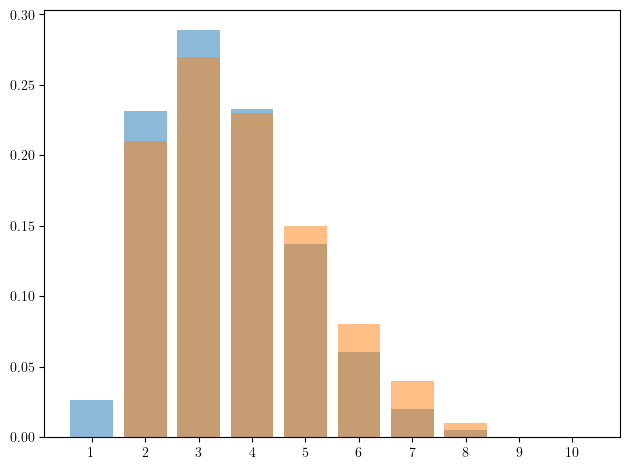

In [40]:
plt.bar(np.arange(1,11),f/sum(f), alpha=0.5)
plt.bar(np.arange(1,11), [0,0.21,0.27,0.23,0.15,0.08,0.04,0.01,0.00,0.00], alpha=0.5)
plt.xticks(np.arange(1,11))
plt.tight_layout()